In [ ]:
import streamlit as st
import pandas as pd


from mainnet_launch.constants import AutopoolConstants, CACHE_TIME, AUTO_ETH, eth_client
from mainnet_launch.lens_contract import get_pools_and_destinations_call
from mainnet_launch.data_fetching.get_state_by_block import get_raw_state_by_blocks, build_blocks_to_use
from mainnet_launch.destinations import DestinationDetails, get_destination_details
from mainnet_launch.autopool_diagnostics.autopool_diagnostics_tab import fetch_destination_totalEthValueHeldIfNoDiscount



@st.cache_data(ttl=CACHE_TIME)
def fetch_destination_totalEthValueHeldIfNoDiscount(autopool: AutopoolConstants, blocks):
    details = [d for d in get_destination_details() if d.autopool == autopool]
    # autopoolNav in Idle df
    lp_token_addresss_to_name = {d.lpTokenAddress: d.vault_name for d in details if d.lpTokenAddress is not None}
    
    pool_and_destinations_df = get_raw_state_by_blocks([get_pools_and_destinations_call()], blocks)
    
    def _extract_totalEthValueHeldIfNoDiscount(row:dict):
        
        for (a, destination_list) in zip(row['autopools'], row['destinations']):
            if a['poolAddress'].lower() == autopool.autopool_eth_addr.lower():               
                # overestimate because we hold more of the discounted asset than if the price was at peg
                # The invarients have the LP always holding more of the less valueable asset
                
                totalEthValueHeldIfNoDiscount = {autopool.name: a['totalIdle'] / 1e18} # ETH in idle is not at any disocunt
                
                for dest in destination_list:
                    discounts = [lst_stats["discount"] / 1e18 for lst_stats in dest["lstStatsData"]]
                    valueHeldInEth = [t["valueHeldInEth"] / 1e18 for t in dest["underlyingTokenValueHeld"]]
                    # a positive discount means we think the destination is trading at below its backing on the consensus layer
                    # a negative disocunt means we think the destination is trading at more than the backing on the consensus layer
                    valueHeldInEth_removed_lst_discount = float(sum([value / (1 - discount) for discount, value, in zip(discounts, valueHeldInEth)]))
                    destination_name = lp_token_addresss_to_name[eth_client.toChecksumAddress(dest['lpTokenAddress'])]
                    
                    if destination_name not in totalEthValueHeldIfNoDiscount:
                        totalEthValueHeldIfNoDiscount[destination_name] = valueHeldInEth_removed_lst_discount
                    else:
                        totalEthValueHeldIfNoDiscount[destination_name] += valueHeldInEth_removed_lst_discount
            
        return totalEthValueHeldIfNoDiscount
    
    def _extract_total_shares(row:dict):
        for (a, _) in zip(row['autopools'], row['destinations']):
            if a['poolAddress'].lower() == autopool.autopool_eth_addr.lower():
                return a['totalSupply'] / 1e18
    
    total_shares = pool_and_destinations_df['getPoolsAndDestinations'].apply(_extract_total_shares)
    
    eth_value_if_no_discount_df = pd.DataFrame.from_records(
        pool_and_destinations_df['getPoolsAndDestinations'].apply(_extract_totalEthValueHeldIfNoDiscount),
        index= pool_and_destinations_df.index)

    eth_value_if_no_discount_df['total_eth_value'] = eth_value_if_no_discount_df.sum(axis=1)
    eth_value_if_no_discount_df['total_shares'] = total_shares
    eth_value_if_no_discount_df['nav_per_share_if_no_discount'] =  eth_value_if_no_discount_df['total_eth_value'] / eth_value_if_no_discount_df['total_shares']


    return eth_value_if_no_discount_df[['nav_per_share_if_no_discount']]


blocks = build_blocks_to_use()
# put these in the bridge plots
eth_value_if_no_discount_df, eth_value_if_with_discount_df = fetch_destination_totalEthValueHeldIfNoDiscount(AUTO_ETH, blocks)


In [ ]:
import streamlit as st
import pandas as pd


from mainnet_launch.constants import AutopoolConstants, CACHE_TIME, AUTO_ETH, eth_client
from mainnet_launch.lens_contract import get_pools_and_destinations_call
from mainnet_launch.data_fetching.get_state_by_block import get_raw_state_by_blocks, build_blocks_to_use
from mainnet_launch.destinations import DestinationDetails, get_destination_details



# @st.cache_data(ttl=CACHE_TIME)
def fetch_destination_totalEthValueHeldIfNoDiscount(autopool: AutopoolConstants, blocks):
    details = [d for d in get_destination_details() if d.autopool == autopool]
    # autopoolNav in Idle df
    lp_token_addresss_to_name = {d.lpTokenAddress: d.vault_name for d in details if d.lpTokenAddress is not None}
    
    pool_and_destinations_df = get_raw_state_by_blocks([get_pools_and_destinations_call()], blocks)
    
    def _extract_totalEthValueHeldIfNoDiscount(row:dict):
        
        for (a, destination_list) in zip(row['autopools'], row['destinations']):
            if a['poolAddress'].lower() == autopool.autopool_eth_addr.lower():
                # over estimated because 
                
                
                totalEthValueHeldIfNoDiscount = {autopool.name: a['totalIdle']/1e18} # ETH in idle is not at any disocunt
                
                for dest in destination_list:
                    discounts = [lst_stats["discount"] / 1e18 for lst_stats in dest["lstStatsData"]]
                    valueHeldInEth = [t["valueHeldInEth"] / 1e18 for t in dest["underlyingTokenValueHeld"]]
                    # a positive discount means we think the destination is trading at below its backing on the consensus layer
                    # a negative disocunt means we think the destination is trading at more than the backing on the consensus layer
                    valueHeldInEth_removed_lst_discount = float(sum([value / (1 - discount) for discount, value, in zip(discounts, valueHeldInEth)]))
                    destination_name = lp_token_addresss_to_name[eth_client.toChecksumAddress(dest['lpTokenAddress'])]
                    
                    if destination_name not in totalEthValueHeldIfNoDiscount:
                        totalEthValueHeldIfNoDiscount[destination_name] = valueHeldInEth_removed_lst_discount
                    else:
                        totalEthValueHeldIfNoDiscount[destination_name] += valueHeldInEth_removed_lst_discount
            
        return totalEthValueHeldIfNoDiscount
    
    def _extract_totalEthValueHeldWithDiscount(row:dict):
        
        for (a, destination_list) in zip(row['autopools'], row['destinations']):
            if a['poolAddress'].lower() == autopool.autopool_eth_addr.lower():
                
                
                totalEthValueHeldWithDiscount = {autopool.name: a['totalIdle']/1e18}
                
                for dest in destination_list:
                    
                    valueHeldInEth = sum([t["valueHeldInEth"] / 1e18 for t in dest["underlyingTokenValueHeld"]])
    
                    destination_name = lp_token_addresss_to_name[eth_client.toChecksumAddress(dest['lpTokenAddress'])]
                    
                    if destination_name not in totalEthValueHeldWithDiscount:
                        totalEthValueHeldWithDiscount[destination_name] = valueHeldInEth
                    else:
                        totalEthValueHeldWithDiscount[destination_name] += valueHeldInEth
            
        return totalEthValueHeldWithDiscount
    
    
    def _extract_total_shares(row:dict):
        for (a, _) in zip(row['autopools'], row['destinations']):
            if a['poolAddress'].lower() == autopool.autopool_eth_addr.lower():
                return a['totalSupply'] / 1e18
    
    total_shares = pool_and_destinations_df['getPoolsAndDestinations'].apply(_extract_total_shares)
    
    eth_value_if_no_discount_df = pd.DataFrame.from_records(
        pool_and_destinations_df['getPoolsAndDestinations'].apply(_extract_totalEthValueHeldIfNoDiscount),
        index= pool_and_destinations_df.index)

    eth_value_if_no_discount_df['total_eth_value'] = eth_value_if_no_discount_df.sum(axis=1)
    eth_value_if_no_discount_df['total_shares'] = total_shares
    eth_value_if_no_discount_df['nav_per_share'] =  eth_value_if_no_discount_df['total_eth_value'] / eth_value_if_no_discount_df['total_shares']

    
    eth_value_if_with_discount_df = pd.DataFrame.from_records(
        pool_and_destinations_df['getPoolsAndDestinations'].apply(_extract_totalEthValueHeldWithDiscount),
        index= pool_and_destinations_df.index)

    eth_value_if_with_discount_df['total_eth_value'] = eth_value_if_with_discount_df.sum(axis=1)
    eth_value_if_with_discount_df['total_shares'] = total_shares
    eth_value_if_with_discount_df['nav_per_share'] =  eth_value_if_with_discount_df['total_eth_value'] / eth_value_if_with_discount_df['total_shares']

    
    return eth_value_if_no_discount_df, eth_value_if_with_discount_df


blocks = build_blocks_to_use()
# put these in the bridge plots
eth_value_if_no_discount_df, eth_value_if_with_discount_df = fetch_destination_totalEthValueHeldIfNoDiscount(AUTO_ETH, blocks)


2024-11-05 13:54:16.944 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-05 13:54:16.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-05 13:54:16.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-05 13:54:16.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-05 13:54:16.947 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-05 13:54:16.947 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-05 13:54:16.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-11-05 13:54:16.949 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

/tmp/ipykernel_63743/3381209625.py:72: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_63743/3381209625.py:81: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [17]:
import plotly.express as px
import plotly.io as pio
pio.templates.default = None

for col in eth_value_if_no_discount_df.columns:
    small_df = pd.concat([eth_value_if_no_discount_df[col], eth_value_if_with_discount_df[col]], axis=1)
    small_df.columns = [f'{col} No Discount', f'{col} With Discount']
    fig = px.line(small_df, title='value with or without discount')
    fig.show()

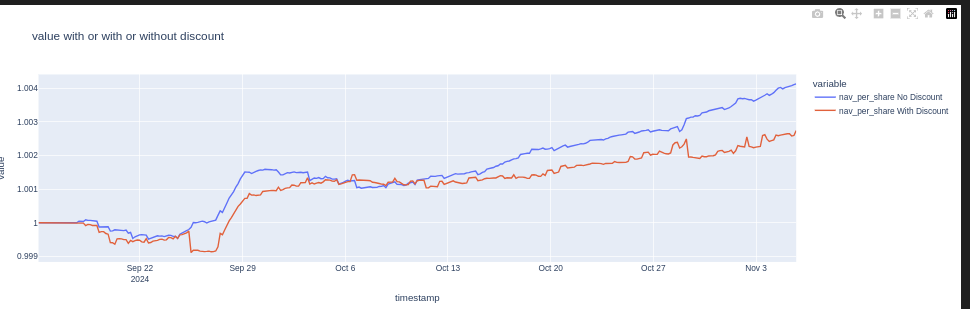

does this imply we have yet to realize a 17bips increase in price return?
We won't get that because while in a depeg. the details matter a lot. 




In [ ]:
for col in 

In [ ]:
from mainnet_launch.lens_contract import get_pools_and_destinations_call
from mainnet_launch.data_fetching.get_state_by_block import get_state_by_one_block


def _fetch_current_destinations(block):
    pool_and_destinations_info = get_state_by_one_block([get_pools_and_destinations_call()], block)

    destinations = []

    for dest_list in pool_and_destinations_info["getPoolsAndDestinations"]["destinations"]:
        for dest in dest_list:

            discounts = [lst_stats["discount"] / 1e18 for lst_stats in dest["lstStatsData"]]
            valueHeldInEth = [t["valueHeldInEth"] / 1e18 for t in dest["underlyingTokenValueHeld"]]
            dest["discounts"] = discounts
            dest["valueHeldInEth"] = valueHeldInEth
            valueHeldInEth_removed_lst_discount = [
                value / (1 - discount) for discount, value, in zip(discounts, valueHeldInEth)
            ]
            dest["underlyingTokenValueHeld_less_discount"] = valueHeldInEth_removed_lst_discount
            destinations.append(dest)

    return destinations


vault_address = "0xbA1462f43c6f60ebD1C62735c94E428aD073E01A".lower()
destinations = _fetch_current_destinations(21114974)

In [ ]:
destinations[0]["underlyingTokenValueHeld"]

[{'valueHeldInEth': 2073209019971884989522},
 {'valueHeldInEth': 852710215233743103167}]

In [ ]:
# nav,
# nav per share if no depeg

In [ ]:
for dest in destinations:
    print(f"{dest['lpTokenName']=}")
    print(f"{dest['discounts']=}")
    print(f"{dest['valueHeldInEth']=}")
    print(f"{dest['underlyingTokenValueHeld_less_discount']=}")
    print("--")

dest['lpTokenName']='Balancer pxETH/wETH StablePool'
dest['discounts']=[0.002497558915905284, 0.0]
dest['valueHeldInEth']=[2073.209019971885, 852.710215233743]
dest['underlyingTokenValueHeld_less_discount']=[2078.399946288555, 852.710215233743]
--
dest['lpTokenName']='wETH/rETH'
dest['discounts']=[0.0, 0.002056059934234273]
dest['valueHeldInEth']=[0.0, 0.0]
dest['underlyingTokenValueHeld_less_discount']=[0.0, 0.0]
--
dest['lpTokenName']='Balancer wstETH-WETH Stable Pool'
dest['discounts']=[0.00041854, 0.0]
dest['valueHeldInEth']=[0.0, 0.0]
dest['underlyingTokenValueHeld_less_discount']=[0.0, 0.0]
--
dest['lpTokenName']='pxETH/wETH'
dest['discounts']=[0.0, 0.002497558915905284]
dest['valueHeldInEth']=[762.6000090271289, 1680.9064762605815]
dest['underlyingTokenValueHeld_less_discount']=[762.6000090271289, 1685.115150629363]
--
dest['lpTokenName']='pxETH/stETH'
dest['discounts']=[0.002497558915905284, 0.00041854]
dest['valueHeldInEth']=[1070.111521647925, 517.8541633900732]
dest['underly

In [ ]:
[lst_stats["discount"] / 1e18 for lst_stats in dest["lstStatsData"]]

[0.002497558915905284, 0.0]

In [ ]:
[t["valueHeldInEth"] for t in dest["underlyingTokenValueHeld"]]

[2073209019971884989522, 852710215233743103167]

In [ ]:
[t["symbol"] for t in dest["underlyingTokenSymbols"]]

['pxETH', 'WETH']

In [ ]:
# We think pxETH is worth 0.002497558915905284 less than it is, so to contradict that we get

In [ ]:
we_think_is_worth = 99
seen_discount = 0.01
we_think_is_worth / (1 - seen_discount)

100.0

In [ ]:
we_think_is_worth = 101
seen_discount = -0.01
we_think_is_worth / (1 - seen_discount)

100.0

In [ ]:
dest["lpTokenName"]

'Balancer pxETH/wETH StablePool'

In [ ]:
breal

In [ ]:
# could it get the current discount() of a token

In [ ]:
from mainnet_launch.lens_contract import get_pools_and_destinations_call
from mainnet_launch.data_fetching.get_state_by_block import get_state_by_one_block, identity_with_bool_success

block = 21114974
pool_and_destinations_info = get_state_by_one_block([get_pools_and_destinations_call()], block)
pool_and_destinations_info

vault_address = '0x3f55eedde51504e6ed0ec30e8289b4da11edb7f9'

for dest_list in pool_and_destinations_info['getPoolsAndDestinations']['destinations']:
    for dest in dest_list:
        if dest['vaultAddress'] == vault_address:
            # a_dest = dest


def extract_underlying_tokens(data):
    # Extract underlying token symbols and addresses
    token_info = data.get("underlyingTokens", [])
    token_symbols = data.get("underlyingTokenSymbols", [])

    # Pair each token symbol with its address
    token_pairs = [(symbol["symbol"], token["tokenAddress"]) for symbol, token in zip(token_symbols, token_info)]

    return token_pairs


all_pairs = []
for dest_list in pool_and_destinations_info["getPoolsAndDestinations"]["destinations"]:
    for dest in dest_list:
        all_pairs.extend(extract_underlying_tokens(dest))

underlying_token_underlying_token_symbol = list(set(all_pairs))

from mainnet_launch.solver_diagnostics.fetch_rebalance_events import ROOT_PRICE_ORACLE
from multicall import Call



def getPriceInEth_call(name: str, token_address: str) -> Call:
    return Call(
        ROOT_PRICE_ORACLE,
        ["getPriceInEth(address)(uint256)", token_address],
        [(name, identity_with_bool_success)],
    )

prices_calls = [getPriceInEth_call(symbol, addr) for symbol, addr in underlying_token_underlying_token_symbol]
price_data = get_state_by_one_block(prices_calls, block)


from multicall import Call

# a_dest = pool_and_destinations_info["getPoolsAndDestinations"]["destinations"][0][4]
def _compute_quanity_of_tokens_in_pool(price_data: dict, a_dest: dict):
    underlyingTokenValueHeld = a_dest["underlyingTokenValueHeld"]
    reserve_eth_value = a_dest[
        "reservesInEth"
    ]  # total ETH value in teh pool in each token priced in terms of ROOT_PRICE_ORACLE.getPriceInETH

    percent_ownership_of_the_pool = a_dest["autoPoolOwnsShares"] / a_dest["actualLPTotalSupply"]
    token_0_price_in_eth = price_data[a_dest["underlyingTokenSymbols"][0]["symbol"]]
    token_1_price_in_eth = price_data[a_dest["underlyingTokenSymbols"][1]["symbol"]]

    reserve_token_0_quantites = int((1e18 * reserve_eth_value[0]) // token_0_price_in_eth)
    reserve_token_1_quantites = int((1e18 *reserve_eth_value[1]) // token_1_price_in_eth)
    
    return {
        a_dest['underlyingTokenSymbols'][0]['symbol']: reserve_token_0_quantites, 
        a_dest['underlyingTokenSymbols'][1]['symbol']: reserve_token_1_quantites
    }

expected_normalized_quanities = _compute_quanity_of_tokens_in_pool(price_data, a_dest)


balance_of_token_0 = Call(
    a_dest['underlyingTokens'][0]['tokenAddress'],
    ["balanceOf(address)(uint256)", a_dest['dexPool']] ,
    [(a_dest['underlyingTokenSymbols'][0]['symbol'] + ' pool balance', identity_with_bool_success)],
)

balance_of_token_1 = Call(
    a_dest['underlyingTokens'][1]['tokenAddress'],
    ["balanceOf(address)(uint256)", a_dest['dexPool']] ,
    [(a_dest['underlyingTokenSymbols'][1]['symbol'] + ' pool balance', identity_with_bool_success)],
)

correct_balance_of = get_state_by_one_block([balance_of_token_0, balance_of_token_1], block)
reserves_in_eth_value = a_dest[ "reservesInEth"]
token_0_price_in_eth = price_data[a_dest["underlyingTokenSymbols"][0]["symbol"]]
token_1_price_in_eth = price_data[a_dest["underlyingTokenSymbols"][1]["symbol"]]


reserves_in_eth_0 = reserves_in_eth_value
price_in_eth_0 = token_0_price_in_eth
divisor = 1e18
correct_balance_of = 2703483004015000777959
# correct_balance_of = 2703483004015000777959
# price_in_eth_0 * 
# reserves_in_eth_value, correct_balance_of, [token_0_price_in_eth, token_1_price_in_eth]
# in ETH terms these are very close
# (correct_balance_of['pxETH'] - expected_normalized_quanities['pxETH']), correct_balance_of['stETH'] - expected_normalized_quanities['stETH'], 

IndentationError: expected an indented block after 'if' statement on line 12 (3061072319.py, line 16)

In [ ]:
# from multicall import Call

# a_dest = pool_and_destinations_info["getPoolsAndDestinations"]["destinations"][0][4]
# def _compute_quanity_of_tokens_in_pool(price_data: dict, a_dest: dict):
#     underlyingTokenValueHeld = a_dest["underlyingTokenValueHeld"]
#     reserve_eth_value = a_dest[
#         "reservesInEth"
#     ]  # total ETH value in teh pool in each token priced in terms of ROOT_PRICE_ORACLE.getPriceInETH

#     percent_ownership_of_the_pool = a_dest["autoPoolOwnsShares"] / a_dest["actualLPTotalSupply"]
#     token_0_price_in_eth = price_data[a_dest["underlyingTokenSymbols"][0]["symbol"]]
#     token_1_price_in_eth = price_data[a_dest["underlyingTokenSymbols"][1]["symbol"]]

#     reserve_token_0_quantites = int((1e18 * reserve_eth_value[0]) // token_0_price_in_eth)
#     reserve_token_1_quantites = int((1e18 *reserve_eth_value[1]) // token_1_price_in_eth)

#     return {
#         a_dest['underlyingTokenSymbols'][0]['symbol']: reserve_token_0_quantites,
#         a_dest['underlyingTokenSymbols'][1]['symbol']: reserve_token_1_quantites
#     }

# expected_normalized_quanities = _compute_quanity_of_tokens_in_pool(price_data, a_dest)


# balance_of_token_0 = Call(
#     a_dest['underlyingTokens'][0]['tokenAddress'],
#     ["balanceOf(address)(uint256)", a_dest['dexPool']] ,
#     [(a_dest['underlyingTokenSymbols'][0]['symbol'], identity_with_bool_success)],
# )

# balance_of_token_1 = Call(
#     a_dest['underlyingTokens'][1]['tokenAddress'],
#     ["balanceOf(address)(uint256)", a_dest['dexPool']] ,
#     [(a_dest['underlyingTokenSymbols'][1]['symbol'], identity_with_bool_success)],
# )

# correct_balance_of = get_state_by_one_block([balance_of_token_0, balance_of_token_1], block)
# # in ETH terms these are very close
# (correct_balance_of['pxETH'] - expected_normalized_quanities['pxETH']), correct_balance_of['stETH'] - expected_normalized_quanities['stETH'],

In [ ]:
from mainnet_launch.lens_contract import get_pools_and_destinations_call
from mainnet_launch.data_fetching.get_state_by_block import get_state_by_one_block, identity_with_bool_success
from mainnet_launch.solver_diagnostics.fetch_rebalance_events import ROOT_PRICE_ORACLE
from multicall import Call


def getPriceInEth_call(name: str, token_address: str) -> Call:
    return Call(
        ROOT_PRICE_ORACLE,
        ["getPriceInEth(address)(uint256)", token_address],
        [(name, identity_with_bool_success)],
    )


def extract_underlying_tokens(data):
    token_info = data.get("underlyingTokens", [])
    token_symbols = data.get("underlyingTokenSymbols", [])
    return [(symbol["symbol"], token["tokenAddress"]) for symbol, token in zip(token_symbols, token_info)]


def _fetch_price_and_destination_data(block, vault_address):
    pool_and_destinations_info = get_state_by_one_block([get_pools_and_destinations_call()], block)

    # Collect unique underlying tokens
    all_pairs = []
    for dest_list in pool_and_destinations_info["getPoolsAndDestinations"]["destinations"]:
        for dest in dest_list:
            all_pairs.extend(extract_underlying_tokens(dest))
    underlying_token_underlying_token_symbol = list(set(all_pairs))

    # Create price calls for underlying tokens
    prices_calls = [getPriceInEth_call(symbol, addr) for symbol, addr in underlying_token_underlying_token_symbol]
    price_data = get_state_by_one_block(prices_calls, block)

    for dest_list in pool_and_destinations_info["getPoolsAndDestinations"]["destinations"]:
        for dest in dest_list:
            if dest["vaultAddress"] == vault_address:
                return price_data, dest

    raise ValueError("failed to find dest")


def analyze_pool_quantities(block, vault_address):

    price_data, dest = _fetch_price_and_destination_data(block, vault_address)
    clean_response = {}
    clean_response["block"] = block
    clean_response["vault_address"] = vault_address
    # clean_response['lst_stats'] = dest['lstStatsData']

    clean_response["discount_0"] = int(1e18 - dest["lstStatsData"][0]["discount"])
    clean_response["discount_1"] = int(1e18 - dest["lstStatsData"][1]["discount"])

    clean_response["reservesInETH_0_less_discount"] = int(
        int(1e18 * clean_response["reservesInETH_0"]) // clean_response["discount_0"]
    )
    clean_response["reservesInETH_1_less_discount"] = int(
        int(1e18 * clean_response["reservesInETH_1"]) // clean_response["discount_1"]
    )

    return clean_response


vault_address = "0xbA1462f43c6f60ebD1C62735c94E428aD073E01A".lower()
diff = analyze_pool_quantities(21114974, vault_address)
diff

{'expected_quantites_WETH': 1046503671399049330688,
 'expected_quantites_pxETH': 2312456295553303314432,
 'token_0_price_in_eth': 1000000000000000000,
 'token_1_price_in_eth': 997502441084094716,
 'reservesInETH_0': 1046503671399049336551,
 'reservesInETH_1': 2306680799714703164495,
 'symbol0': 'WETH',
 'symbol1': 'pxETH',
 'block': 21114974,
 'vault_address': '0xba1462f43c6f60ebd1c62735c94e428ad073e01a',
 'discount_0': 1000000000000000000,
 'discount_1': 997502441084094720,
 'reservesInETH_0_less_discount': 1046503671399049314107,
 'reservesInETH_1_less_discount': 2312456295553303421324}

In [ ]:
1046503671399049314107 - 1046503671399049330688

-16581

In [ ]:
2312456295553303314432 - 2312456295553303314432

0

In [ ]:
2312456295553303314432 - 2312456295553303576576

-262144

#

In [ ]:
dest["underlyingTokenSymbols"]

[{'symbol': 'WETH'}, {'symbol': 'pxETH'}]

In [ ]:
diff

{'expected_quantites_WETH': 1046503671399049330688,
 'expected_quantites_pxETH': 2312456295553303314432,
 'token_0_price_in_eth': 1000000000000000000,
 'token_1_price_in_eth': 997502441084094716,
 'reservesInETH_0': 1046503671399049336551,
 'reservesInETH_1': 2306680799714703164495,
 'symbol0': 'WETH',
 'symbol1': 'pxETH',
 'block': 21114974,
 'vault_address': '0xba1462f43c6f60ebd1c62735c94e428ad073e01a'}

In [ ]:
# reserves in ETH if not discounted
# we think os ETh is worth 99% of the value on teh duernling

market_price_value = 1_000
discount = -0.001359361498918978
market_price_value / (1 + discount)
# how accurate is the discount value

1001.3612118779378

In [ ]:
lst_stats = dest["lstStatsData"]
lst_stats

[{'lastSnapshotTimestamp': 1730692907,
  'baseApr': 29089230467150729,
  'discount': -1359361498918978,
  'discountHistory': (0, 0, 0, 0, 0, 0, 0, 0, 0, 0),
  'discountTimestampByPercent': 0},
 {'lastSnapshotTimestamp': 1730692907,
  'baseApr': 24729041045672722,
  'discount': 2056059934234273,
  'discountHistory': (916, 0, 1793, 46456, 13280, 0, 0, 4582, 0, 0),
  'discountTimestampByPercent': 0}]

In [ ]:
(lst_stats[0]["discount"] / 1e18)

-0.001359361498918978

In [ ]:
osETH_discount = 1 - (lst_stats[0]["discount"] / 1e18)

1.001359361498919

In [ ]:
# 2056059934234273 /1e18 # th

0.002056059934234273

In [ ]:
diff

{'expected_quantites_osETH': 2703477041183030509568,
 'expected_quantites_rETH': 3273160054805431320576,
 'token_0_price_in_eth': 1032089470000000000,
 'token_1_price_in_eth': 1117645592912307500,
 'reservesInETH_0': 2790230186591762225044,
 'reservesInETH_1': 3658232910149897200866,
 'symbol0': 'osETH',
 'symbol1': 'rETH',
 'block': 21114974,
 'vault_address': '0x3f55eedde51504e6ed0ec30e8289b4da11edb7f9'}

In [ ]:
# Can I use this?

resre

In [ ]:
blocks

NameError: name 'blocks' is not defined

In [ ]:
blo

In [ ]:
# from mainnet_launch.lens_contract import get_pools_and_destinations_call
# from mainnet_launch.data_fetching.get_state_by_block import get_state_by_one_block, identity_with_bool_success
# from mainnet_launch.solver_diagnostics.fetch_rebalance_events import ROOT_PRICE_ORACLE
# from multicall import Call

# from mainnet_launch.data_fetching.get_state_by_block import build_blocks_to_use

# blocks = build_blocks_to_use()[::4][::-4]


# def getPriceInEth_call(name: str, token_address: str) -> Call:
#     return Call(
#         ROOT_PRICE_ORACLE,
#         ["getPriceInEth(address)(uint256)", token_address],
#         [(name, identity_with_bool_success)],
#     )

# def extract_underlying_tokens(data):
#     token_info = data.get("underlyingTokens", [])
#     token_symbols = data.get("underlyingTokenSymbols", [])
#     return [(symbol["symbol"], token["tokenAddress"]) for symbol, token in zip(token_symbols, token_info)]


# def _compute_quantity_of_tokens_in_pool(price_data: dict, a_dest: dict):
#     reserve_eth_value = a_dest["reservesInEth"]

#     token_0_price_in_eth = price_data[a_dest["underlyingTokenSymbols"][0]["symbol"]]
#     token_1_price_in_eth = price_data[a_dest["underlyingTokenSymbols"][1]["symbol"]]


#     reserve_token_0_quantities = int((1e18 * reserve_eth_value[0]) // token_0_price_in_eth)
#     reserve_token_1_quantities = int((1e18 * reserve_eth_value[1]) // token_1_price_in_eth)

#     return {
#         a_dest['underlyingTokenSymbols'][0]['symbol']: reserve_token_0_quantities, # order is backwards
#         a_dest['underlyingTokenSymbols'][1]['symbol']: reserve_token_1_quantities
#     }

# def _get_reserves_eth_from_destination(vault_address:str):

# def analyze_pool_quantities(block):
#     # Fetch pool and destinations information at the given block
#     pool_and_destinations_info = get_state_by_one_block([get_pools_and_destinations_call()], block)

#     # Collect unique underlying tokens
#     all_pairs = []
#     for dest_list in pool_and_destinations_info["getPoolsAndDestinations"]["destinations"]:
#         for dest in dest_list:
#             all_pairs.extend(extract_underlying_tokens(dest))
#     underlying_token_underlying_token_symbol = list(set(all_pairs))

#     # Create price calls for underlying tokens
#     prices_calls = [getPriceInEth_call(symbol, addr) for symbol, addr in underlying_token_underlying_token_symbol]
#     price_data = get_state_by_one_block(prices_calls, block)

#     # Select a destination to analyze
#     a_dest = None #pool_and_destinations_info["getPoolsAndDestinations"]["destinations"][0][4]

#     vault_address = '0x3f55eedde51504e6ed0ec30e8289b4da11edb7f9'

#     for dest_list in pool_and_destinations_info['getPoolsAndDestinations']['destinations']:
#         for dest in dest_list:
#             if dest['vaultAddress'] == vault_address:
#                 a_dest = dest

#     if a_dest is None:
#         return {}

#     # Compute expected normalized quantities
#     expected_normalized_quantities = _compute_quantity_of_tokens_in_pool(price_data, a_dest)

#     # Fetch actual balances in the pool
#     balance_of_token_0 = Call(
#         a_dest['underlyingTokens'][0]['tokenAddress'],
#         ["balanceOf(address)(uint256)", a_dest['dexPool']],
#         [(a_dest['underlyingTokenSymbols'][0]['symbol'], identity_with_bool_success)],
#     )
#     balance_of_token_1 = Call(
#         a_dest['underlyingTokens'][1]['tokenAddress'],
#         ["balanceOf(address)(uint256)", a_dest['dexPool']],
#         [(a_dest['underlyingTokenSymbols'][1]['symbol'], identity_with_bool_success)],
#     )

#     correct_balance_of = get_state_by_one_block([balance_of_token_0, balance_of_token_1], block)

#     # Compute differences in ETH terms
#     token_0_symbol = a_dest['underlyingTokenSymbols'][0]['symbol']
#     token_1_symbol = a_dest['underlyingTokenSymbols'][1]['symbol']

#     difference_token_0 = correct_balance_of[token_0_symbol] - expected_normalized_quantities[token_0_symbol]
#     difference_token_1 = correct_balance_of[token_1_symbol] - expected_normalized_quantities[token_1_symbol]

#     return {'difference_token_0': difference_token_0 /1e18, 'difference_token_1': difference_token_1 /1e18 , 'a_dest':a_dest}


# from mainnet_launch.data_fetching.get_state_by_block import build_blocks_to_use

# blocks = build_blocks_to_use()[::4][::-4]
# differences = [analyze_pool_quantities(block) for block in blocks]

# import pandas as pd
# import plotly.express as px
# diff_df = pd.DataFrame.from_records(differences)
# px.line(diff_df[['difference_token_0', 'difference_token_1']])